# **Trabajo Práctico: La Gran Prueba de Sabor**

# **Presentación**



**Una consultora** ha sido contratada para realizar un **análisis de mercado** y **proporcionar recomendaciones estratégicas** para la apertura de una cafetería en EE.UU.  

Se le solicitó llevar a cabo un estudio utilizando los datos de la encuesta [**"La Gran Prueba de Sabor"**](https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv), con el fin de extraer información sobre las preferencias de los consumidores y ayudar al grupo inversor a diseñar una estrategia informada para su incursión en el sector. Esta encuesta la realizó el famoso barista *James Hoffmann* en octubre de 2023, durante una transmisión en vivo con unas *4.000 personas* en Estados Unidos.

#**Objetivo del Proyecto Final**

En este Proyecto Final, el alumno asumirá el rol de consultor y aplicará todos los conocimientos adquiridos en la materia. Deberá demostrar un uso adecuado de los elementos y construcciones del lenguaje de programación mediante la lectura, manipulación y análisis de los datos de la encuesta, así como proporcionar información útil para el inversor.

#**Consignas**


## **Etapa 0.**
**Conociendo los datos**


**1-** Descargar el archivo de la encuesta ejecutando el código que se propone a continuación.

**2-** Una vez descargado el archivo analice su contenido. ¿Qué información brinda de cada persona encuestada? ¿Todos los encuestados respondieron a todas las preguntas?

In [1]:
#No modificar este código que le permitirá bajar el archivo que necesita para trabajar

import requests

url_coffee_survey = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv"
archivo_salida_coffee_survey = "coffee_survey.csv"

def descargarCSV(url, archivo_salida):
    print("Descargando archivo...")
    consulta = requests.get(url)
    contenido = consulta.content

    print("Guardando archivo...")
    # Abrir conexion en modo escritura
    with open(archivo_salida, "w", encoding="utf-8") as archivo:
        # Escribir el contenido de la consulta
        archivo.write(contenido.decode("utf-8"))

    print("¡Archivo descargado con éxito!")

descargarCSV(url_coffee_survey,archivo_salida_coffee_survey)


Descargando archivo...
Guardando archivo...
¡Archivo descargado con éxito!


**Respuesta a la Consigna 2:**

Las personas encuestadas responden a preguntas personales como su edad, sexo, étnia, familia, nivel eduactivo, ingresos, etc. y preguntas relacionadas al consumo de café como sus preferencias, experiencias, gustos en café, lugares dónde toma café, cómo lo prepara, etc. En el archivo .csv se puede notar respuestas "NA" que significan que la persona no respondió a la pregunta.

## **Etapa 1.**
**Analizando las respuestas**

**3-** Analice la columna *'age'* que indica el rango de edad del encuestado. ¿Qué cantidad de los encuestados que brindaron esta información pertenecen a los rangos *'<18 years old'*, *'18-24 years old'*, *'25-34 years old'*, *'35-44 years old'*, *'45-54 years old'*, *'55-64 years old'* y *'>65 years old'*, respectivamente? Para responder a esta pregunta implemente una función **contar_rangos_edad** que reciba el nombre del archivo de datos de la encuesta y devuelva un diccionario que le ayude a contar la cantidad de respuestas de cada rango etario.

In [2]:
x = cargar_datos(archivo_coffee_survey)
type(x)

NameError: name 'cargar_datos' is not defined

In [ ]:
import csv

# --- Defina una función que le sirva para manipular los datos del archivo --- #

archivo_coffee_survey = "coffee_survey.csv"

def cargar_datos(nombre_archivo:str) -> list:
  """
  Carga los datos del archivo de entrada csv. Su salida es una lista compuesta
  por diccionarios que representan a las filas del archivo. Cada diccionario
  tiene como "key" los nombres de las columnas y como "value" el valor en
  esa columna.
  """
  with open(nombre_archivo, encoding="utf-8") as csvfile:
    reader = csv.DictReader(csvfile)
    return list(reader)


# --- Consigna 3: Analizar la columna 'age' --- #

def contar_rangos_edad(nombre_archivo:str) -> dict[str,int]:
  """
  Muestra los valores que aparecen en la columna "age" del archivo de entrada,
  junto con la cantidad de veces que aparece. No considera el valor "NA".
  """
  datos = cargar_datos(nombre_archivo)
  conteo = {}
  for row in datos:
    age_row = row['age']
    if age_row in conteo:
      conteo[age_row] += 1
    elif age_row != 'NA':  # Sacamos del conteo las respuestas 'NA'
      conteo[age_row] = 1
  return conteo

# --- Prueba --- #
print("Conteo de rangos de edad:", contar_rangos_edad("coffee_survey.csv"))

# --- Respuesta esperada: --- #
#Conteo de rangos de edad: {'18-24 years old': 461, '25-34 years old': 1986, '35-44 years old': 960, '55-64 years old': 187, 'NA': 31, '<18 years old': 20, '>65 years old': 95, '45-54 years old': 302}



Conteo de rangos de edad: {'18-24 years old': 461, '25-34 years old': 1986, '35-44 years old': 960, '55-64 years old': 187, '<18 years old': 20, '>65 years old': 95, '45-54 years old': 302}


****Respuesta a la Consigna 3:**** La cantidad de encuestados que brindaron información en la pregunta "age" son (por rangos):
* '<18 years old': 20
* '18-24 years old': 461
* '25-34 years old': 1986
* '35-44 years old': 960
* '45-54 years old': 302
* '55-64 years old': 187
* '>65 years old': 95



**4-** Analice la columna *'where_drink'* que indica dónde toman café los encuestados. ¿Qué diferencia encuentra entre esta columna de la anterior? ¿Qué cantidad de los encuestados que respondieron a esta pregunta toman el café *'On the go'*, *'At a cafe'*, *'At the office'*, *'At home'*, *'None of these'*, respectivamente?  Para responder a esta pregunta implemente una función **contar_lugares_consumo** que reciba el nombre del archivo de datos de la encuesta y devuelva un diccionario que le ayude a contar la cantidad de respuestas de cada lugar de consumo.

In [ ]:
# --- Consigna 4: Analizar la columna 'where_drink' --- #
def contar_lugares_consumo(nombre_archivo) -> dict[str,int]:
  """
  Muestra los valores que aparecen en la columna "where_drink" del archivo de
  entrada, junto con la cantidad de veces que aparece. No considera el valor
  "NA".
  """
  datos = cargar_datos(nombre_archivo)
  conteo = {}
  for row in datos:
    where_drink = row['where_drink'].split(', ') # Lista de string's con las respuestas
    if where_drink[0] != 'NA': # Sacamos del conteo las respuestas 'NA'
      for cadena in where_drink:
        if cadena in conteo:
          conteo[cadena] += 1
        else:
          conteo[cadena] = 1
  return conteo

# --- Prueba --- #
print("Conteo de lugares de consumo:", contar_lugares_consumo("coffee_survey.csv"))

# --- Respuesta esperada: --- #
#Conteo de lugares de consumo: {'On the go': 705, 'At a cafe': 1170, 'At the office': 1430, 'At home': 3644, 'None of these': 36}


Conteo de lugares de consumo: {'At a cafe': 1170, 'At the office': 1430, 'At home': 3644, 'On the go': 705, 'None of these': 36}


****Respuesta a la Consigna 4:****

1) La diferencia entre la columna "where_drink" y la columna "age" es que en la segunda se podía elegir solo una opción, que es el rango donde se encuentra su edad, mientras que en la columna "where_drink" se podían elegir varias opciones entre 'On the go', 'At a cafe', 'At the office', 'At home' y 'None of these'.

2) La cantidad de respuestas para cada opción es:

* 'At a cafe': 1170
* 'At the office': 1430
* 'At home': 3644
* 'On the go': 705
* 'None of these': 36

**5-** Analicen los códigos propuestos para responder a las consignas **3** y **4**. Son similares, ¿verdad? Proponga una función **procesamiento_columna**, que recibiendo el nombre del archivo y el nombre de la columna a analizar, sirva para resolver los dos casos anteriores. La función debe devolver un diccionario con las cantidades asociadas a cada uno de los valores posibles de las respuestas brindadas por los encuestados.


In [ ]:
# --- Consigna 5: Función procesamiento_columna --- #
def procesamiento_columna(nombre_archivo:str, columna:str):
  """
  Muestra los valores que aparecen en la columna "columna" del archivo de
  entrada "nombre_archivo", junto con la cantidad de veces que aparece.
  No considera el valor "NA".
  """
  datos = cargar_datos(nombre_archivo)
  conteo = {}
  for row in datos:
    columna_list = row[columna].split(', ') # Lista de string's con las respuestas
    if columna_list[0] != 'NA': # Sacamos del conteo las respuestas 'NA'
      for cadena in columna_list:
        if cadena in conteo:
          conteo[cadena] += 1
        else:
          conteo[cadena] = 1
  return conteo

# --- Prueba --- #
print("Conteo de rangos de edad:", procesamiento_columna("coffee_survey.csv","age"))
print("Conteo de lugares de consumo:", procesamiento_columna("coffee_survey.csv","where_drink"))

# --- Respuestas esperadas: --- #
#Conteo de rangos de edad: {'18-24 years old': 461, '25-34 years old': 1986, '35-44 years old': 960, '55-64 years old': 187, '<18 years old': 20, '>65 years old': 95, '45-54 years old': 302}
#Conteo de lugares de consumo: {'At a cafe': 1170, 'At the office': 1430, 'At home': 3644, 'On the go': 705, 'None of these': 36}


Conteo de rangos de edad: {'18-24 years old': 461, '25-34 years old': 1986, '35-44 years old': 960, '55-64 years old': 187, '<18 years old': 20, '>65 years old': 95, '45-54 years old': 302}
Conteo de lugares de consumo: {'At a cafe': 1170, 'At the office': 1430, 'At home': 3644, 'On the go': 705, 'None of these': 36}






**6-** Pruebe la función anterior, analizando las columnas *'cups'* y *'brew'*. ¿Funciona?

In [ ]:
# --- Consigna 6: Pruebe la función anterior, analizando las columnas 'cups' y 'brew' --- #

# --- Prueba --- #
print("Conteo de rangos de tazas:", procesamiento_columna("coffee_survey.csv","cups")) # Decía "Conteo de rangos de edad" y lo cambiamos
print("Conteo de lugares de consumo:", procesamiento_columna("coffee_survey.csv","brew"))

# --- Respuestas esperadas: --- #
#Conteo de cups: {'Less than 1': 348, '2': 1663, '1': 1277, '3': 473, 'More than 4': 67, '4': 121}
#Conteo de brew: {'Pod/capsule machine (e.g. Keurig/Nespresso)': 336, 'Bean-to-cup machine': 84, 'Coffee brewing machine (e.g. Mr. Coffee)': 663, 'Pour over': 2295, 'Espresso': 1518, 'French press': 735, 'Instant coffee': 130, 'Other': 677, 'Coffee extract (e.g. Cometeer)': 186, 'Cold brew': 525}


Conteo de rangos de tazas: {'Less than 1': 348, '2': 1663, '1': 1277, '3': 473, 'More than 4': 67, '4': 121}
Conteo de lugares de consumo: {'Pod/capsule machine (e.g. Keurig/Nespresso)': 336, 'Bean-to-cup machine': 84, 'Coffee brewing machine (e.g. Mr. Coffee)': 663, 'Pour over': 2295, 'Espresso': 1518, 'French press': 735, 'Instant coffee': 130, 'Other': 677, 'Coffee extract (e.g. Cometeer)': 186, 'Cold brew': 525}


## **Etapa 2.**
**Carga de la Información de los Consumidores**

**7-** Definir una clase **Consumidor** que tenga los siguientes

  - Atributos:

    `submission_id`: Identificador único del consumidor.

    `age`: Rango de edad (str).

    `gender`: Género (str).

    `cups`: Número de tazas que consume por día (str).

    `where_drink`: Lugares donde consume café (list[str]).

    `favorite`: Café preferido (str).

    `roast_level`: Nivel de tueste (str).

    `caffeine`: Tipo de cafeína (str).

    `education_level`: Nivel de educación (str).

    `employment_status`: Estado o situación laboral (str).

  - Métodos:

    `__init__`: Para inicializar los atributos.

    `__str__`: Para representar al consumidor de manera legible.

  Complete el siguiente código. Agregue todos los argumentos que necesite a los métodos.

In [ ]:
# --- Consigna 7: Definir una clase **Consumidor** --- #

# --- Definimos la clase consumidor --- #
class Consumidor:
    # Definimos el constructor con los atributos
    def __init__(self, submission_id, age, gender, cups, where_drink, favorite, roast_level, caffeine, education_level, employment_status):
        # Inicializamos los atributos con los valores que le pasamos
        self.submission_id = submission_id
        self.age = age
        self.gender = gender
        self.cups = cups
        self.where_drink = where_drink
        self.favorite = favorite
        self.roast_level = roast_level
        self.caffeine = caffeine
        self.education_level = education_level
        self.employment_status = employment_status
    # Definimos como se ve el objeto al hacer print
    def __str__(self):
        return (f"Consumidor {self.submission_id}:\n"
                f"  Edad: {self.age}\n"
                f"  Género: {self.gender}\n"
                f"  Tazas por día: {self.cups}\n"
                f"  Lugares donde toma café: {self.where_drink}\n"
                f"  Café preferido: {self.favorite}\n"
                f"  Nivel de tueste: {self.roast_level}\n"
                f"  Tipo de cafeína: {self.caffeine}\n"
                f"  Nivel de educación: {self.education_level}\n"
                f"  Estado laboral: {self.employment_status}")

In [ ]:
# --- Ejemplo de prueba --- #

cons_prueba = Consumidor("prueba","genero","0","1","lugar","negro","tueste","cafeina","universitario","desempleado")
print(cons_prueba)

Consumidor prueba:
  Edad: genero
  Género: 0
  Tazas por día: 1
  Lugares donde toma café: lugar
  Café preferido: negro
  Nivel de tueste: tueste
  Tipo de cafeína: cafeina
  Nivel de educación: universitario
  Estado laboral: desempleado


**8-** Implemente una función llamada **cargar_consumidores** que reciba como argumento el nombre del archivo de la encuesta y devuelva un diccionario donde la clave sea el `submission_id` (ID del consumidor) y el valor sea una instancia de la clase `Consumidor`.

In [ ]:
# --- Consigna 8: Implemente una función llamada cargar_consumidores --- #

def cargar_consumidores(archivo:str) -> dict[str,'Consumidor']:
  '''
  Carga el archivo de entrada y devuelve un diccionario donde la clave es
  submission_id y el valor es una instancia de la clase Consumidor.
  '''
  consumidor = {}
  datos = cargar_datos(archivo)
  for fila in datos:
    consumidor[fila['submission_id']] = Consumidor(fila['submission_id'], fila['age'],
              fila['gender'], fila['cups'], fila['where_drink'], fila['favorite'], fila['roast_level'],
              fila['caffeine'], fila['education_level'], fila['employment_status'])
  return consumidor

In [ ]:
# --- Ejemplo de prueba --- #
consumidor = cargar_consumidores("coffee_survey.csv")
datos = cargar_datos("coffee_survey.csv") # Función que carga el csv (Etapa 1)

# Elegimos un consumidor y chequeamos sus atributos
i = 122 # Elección de consumidor (número de fila del csv)
cons_id = datos[i]['submission_id']
print(consumidor[cons_id])
print('Fila del csv:')
print('  ', datos[i]['age'])
print('  ', datos[i]['gender'])
print('  ', datos[i]['cups'])
print('  ', datos[i]['where_drink'])
print('  ', datos[i]['favorite'])
print('  ', datos[i]['roast_level'])
print('  ', datos[i]['caffeine'])
print('  ', datos[i]['education_level'])
print('  ', datos[i]['employment_status'])

Consumidor pLPN7q:
  Edad: 35-44 years old
  Género: Male
  Tazas por día: 1
  Lugares donde toma café: At home, At a cafe
  Café preferido: Pourover
  Nivel de tueste: Light
  Tipo de cafeína: Full caffeine
  Nivel de educación: Bachelor's degree
  Estado laboral: Employed full-time
Fila del csv:
   35-44 years old
   Male
   1
   At home, At a cafe
   Pourover
   Light
   Full caffeine
   Bachelor's degree
   Employed full-time


**9-** Implemente una función llamada **filtrar_por_atributo_valor** que reciba un diccionario de consumidores como el creado en el punto anterior, un nombre de atributo (cualquiera de los atributos presentes en la clase Consumidor) y un valor de dicho atributo como argumentos. La función debe recorrer el diccionario y filtrar los consumidores, devolviendo otro diccionario cuyos consumidores hayan pasado el filtro aplicado.

In [ ]:
# --- Consigna 9: Implemente una función llamada filtrar_por_atributo_valor --- #

def filtrar_por_atributo_valor(cons:dict[str,'Consumidor'], atributo:str, valor:str) -> dict[str,'Consumidor']:
  '''
  Filtra el diccionario de consumidores por el atributo y el valor ingresados.

  '''
  cons_filtrado = {}
  for key in cons.keys():
    atributo_cons = getattr(cons[key],atributo).split(", ") # Consideramos que hay preguntas con más de una respuesta
    for i in atributo_cons:
      if i == valor:
        cons_filtrado[key] = cons[key]
  return cons_filtrado

In [ ]:
#--- Ejemplo de prueba ---#
consumidor = cargar_consumidores("coffee_survey.csv")
cons_filtrados = filtrar_por_atributo_valor(consumidor,"age","18-24 years old")

# Podemos chequear con un 'for' que cada consumidor está en el rango de edad:
p = 'Edades correctas!'
for cons in cons_filtrados.values():
  if cons.age != '18-24 years old':
    p = 'Hay edades fuera del rango deseado.'
print(p)

cons_filtrados_2 = filtrar_por_atributo_valor(consumidor,"where_drink","At a cafe")

# Podemos chequear con un 'for' que cada consumidor consume café en el lugar indicado:
p = 'Lugares correctos!'
for cons in cons_filtrados_2.values():
  if 'At a cafe' not in cons.where_drink.split(', '):
    p = 'Hay consumidores fuera del rango deseado.'
print(p)

Edades correctas!
Lugares correctos!


**10-** Invocando a las funciones anteriores, ¿podría crear un diccionario que corresponda a los consumidores de género femenino (*Female*) cuya edad supere los 44 años?

In [ ]:
# --- Consigna 10 --- #

consumidor = cargar_consumidores("coffee_survey.csv")
filtro1 = filtrar_por_atributo_valor(consumidor,"gender","Female")
parte1 = filtrar_por_atributo_valor(filtro1,"age","45-54 years old")
parte2 = filtrar_por_atributo_valor(filtro1,"age","55-64 years old")
parte3 = filtrar_por_atributo_valor(filtro1,"age",">65 years old")

cons_filtrados_final = (parte1|parte2)|parte3 # Observemos que los diccionarios "parte" son disjuntos por conjuntos de key

# Podemos chequear con un 'for' que cada consumidor cumple con las condiciones de filtro:
p = 'Consumidores correctamente filtrados!'
for cons in cons_filtrados_final.values():
  if (cons.age != "45-54 years old") and (cons.age != "55-64 years old") and (cons.age != ">65 years old"):
    p = 'Hay edades fuera del rango deseado.'
  elif cons.gender != "Female":
    p = 'Hay consumidores no femeninos.'
print(p)

Consumidores correctamente filtrados!


## **Etapa 3.**
**Análisis de la Encuesta**

En esta sección, nos proponemos obtener información relevante sobre las preferencias de los consumidores, considerando diferentes criterios como el rango etario y el género.

Desarrolle una clase en Python que permita gestionar las respuestas de la encuesta sobre preferencias de café. Esta clase será capaz de almacenar, analizar y visualizar datos relacionados con las preferencias de café de distintos consumidores, agrupándolos por rangos de edad y género.

***Nota:*** En los análisis que realice, deberá considerar únicamente las respuestas proporcionadas, ignorando los valores NA.

**11-** Definir una clase **Encuesta** que tenga los siguientes

  - Atributos:

    `consumidores`: Diccionario que almacena los datos de los consumidores que respondieron a la encuesta. La clave es el submission_id (ID del consumidor) y el valor es una instancia de la clase `Consumidor`

    `cantidades_grupos_etarios`: Diccionario que contiene la cantidad de consumidores en cada grupo etario. La clave es el grupo etario y el valor es la cantidad de consumidores que respondieron a la encuesta en ese grupo.

    `cantidades_generos`: Diccionario que refleja la cantidad de consumidores de cada género. La clave es el género y el valor es la cantidad de consumidores que respondieron a la encuesta de ese género.

    `cafe_favorito_por_grupo_etario`: Diccionario que tiene como claves cada uno de los grupos etarios y como valor otro diccionario. Este último tiene como claves los cafés favoritos y como valor la cantidad de consumidores que prefieren ese café dentro de ese grupo etario.

    `nivel_de_tueste_preferido_por_genero`: Diccionario que contiene como claves cada uno de los géneros y como valor otro diccionario. Este segundo diccionario tiene como claves los niveles de tueste preferidos y como valor la cantidad de consumidores que prefieren ese nivel de tueste para el género considerado.

    `maximo_nivel_educativo`: El nivel educativo al que pertenece la mayor parte de los consumidores que respondieron a la encuesta.

  - Métodos:

    `__init__`: Para inicializar los atributos.

    `analizar_rangos_edades`: Método que cuenta la cantidad de consumidores en cada rango etario.

    `analizar_generos`: Método que cuenta la cantidad de consumidores de cada género.

    `analizar_cafe_favorito_por_grupos_etarios`: Método que, para cada grupo etario, cuenta cuántos consumidores prefieren cada tipo de café.

    `analizar_nivel_de_tueste_por_genero`: Método que, para cada género, cuenta cuántos consumidores prefieren cada nivel de tueste.

    `calcular_maximo_nivel_educativo`: Método que calcula el nivel educativo que posee la mayor cantidad de consumidores.

    `graficar_grupos_etarios`: Método que realiza un gráfico de torta que muestra el porcentaje de consumidores pertenecientes a cada grupo etario.

    `graficar_cafe_favorito_por_grupos_etarios`: Método que realiza un gráfico de barras para cada grupo etario, mostrando cuántos consumidores prefieren cada tipo de café.

Complete el siguiente código.

In [ ]:
# from _typeshed import Self
import matplotlib.pyplot as plt

# --- Consigna 11: Definir una clase Encuesta --- #

class Encuesta:
  def __init__(self, archivo: str):
    self.consumidores = cargar_consumidores(archivo)
    self.cantidades_grupos_etarios = self.analizar_rangos_edades()
    self.cantidades_generos = self.analizar_rangos_edades()
    self.cafe_favorito_por_grupo_etario = self.analizar_cafe_favorito_por_grupos_etarios()
    self.nivel_de_tueste_preferido_por_genero = self.analizar_nivel_de_tueste_por_genero()
    self.maximo_nivel_educativo = self.calcular_maximo_nivel_educativo()

  def procesamiento_columna(senombre_archivo:str, columna:str):
    """
    Muestra los valores que aparecen en la columna "columna" del archivo de
    entrada "nombre_archivo", junto con la cantidad de veces que aparece.
    No considera el valor "NA".
    """
    datos = cargar_datos(nombre_archivo)
    conteo = {}
    for row in datos:
      columna_list = row[columna].split(', ') # Lista de string's con las respuestas
      if columna_list[0] != 'NA': # Sacamos del conteo las respuestas 'NA'
        for cadena in columna_list:
          if cadena in conteo:
            conteo[cadena] += 1
          else:
            conteo[cadena] = 1
    return conteo

  def analizar_rangos_edades(self) -> dict[str,int]:
    '''
    Método que cuenta la cantidad de consumidores en cada rango etario.
    '''
    conteo = {}
    for key in self.consumidores.keys():
      consumidor = self.consumidores[key]
      if consumidor.age in conteo:
        conteo[consumidor.age] += 1
      elif consumidor.age != 'NA':  # Sacamos del conteo las respuestas 'NA'
        conteo[consumidor.age] = 1
    return conteo

  def analizar_generos(self) -> dict[str,int]:
    '''
    Método que cuenta la cantidad de consumidores de cada género.
    Contamos la respuestas "Other (please specify)" como un solo género.
    '''
    conteo = {}
    for key in self.consumidores.keys():
      consumidor = self.consumidores[key]
      if consumidor.gender in conteo:
        conteo[consumidor.gender] += 1
      elif consumidor.gender != 'NA':  # Sacamos del conteo las respuestas 'NA'
        conteo[consumidor.gender] = 1
    self.cantidades_generos = conteo

  def analizar_cafe_favorito_por_grupos_etarios(self) -> dict[str,dict[str,int]]:
    '''
    Método que, para cada grupo etario, cuenta cuántos consumidores prefieren cada tipo de café.
    '''
    conteo = {}
    for rango_edad in ['18-24 years old', '25-34 years old', '35-44 years old', '55-64 years old', '<18 years old',
                        '>65 years old', '45-54 years old']:
      consfiltrados = filtrar_por_atributo_valor(self.consumidores, 'age', rango_edad)
      conteo_aux = {}
      for key in consfiltrados.keys():
        consumidor = self.consumidores[key]
        if consumidor.favorite in conteo_aux:
          conteo_aux[consumidor.favorite] += 1
        elif consumidor.favorite != 'NA':  # Sacamos del conteo las respuestas 'NA'
          conteo_aux[consumidor.favorite] = 1
      conteo[rango_edad] = conteo_aux
    return conteo

  def analizar_nivel_de_tueste_por_genero(self) -> dict[str,dict[str,int]]:
    '''
    Método que, para cada género, cuenta cuántos consumidores prefieren cada nivel de tueste.
    Contamos la respuestas "Other (please specify)" como un solo género.
    '''
    conteo = {}
    for genero in ['Other (please specify)', 'Female', 'Male', 'Non-binary', 'Prefer not to say']:
      consfiltrados = filtrar_por_atributo_valor(self.consumidores, 'gender', genero)
      conteo_aux = {}
      for key in consfiltrados.keys():
        consumidor = self.consumidores[key]
        if consumidor.roast_level in conteo_aux:
          conteo_aux[consumidor.roast_level] += 1
        elif consumidor.roast_level != 'NA':  # Sacamos del conteo las respuestas 'NA'
          conteo_aux[consumidor.roast_level] = 1
      conteo[genero] = conteo_aux
    return conteo

  def calcular_maximo_nivel_educativo(self) -> str:
    '''
    Método que calcula el nivel educativo que posee la mayor cantidad de consumidores.
    '''
    conteo = {}
    for key in self.consumidores.keys():
      consumidor = self.consumidores[key]
      if consumidor.education_level in conteo:
        conteo[consumidor.education_level] += 1
      elif consumidor.education_level != 'NA':  # Sacamos del conteo las respuestas 'NA'
        conteo[consumidor.education_level] = 1
    return max(conteo, key=conteo.get)

  def graficar_grupos_etarios(self) -> None:
    '''
    Método que realiza un gráfico de torta que muestra el porcentaje de consumidores pertenecientes a cada grupo etario.
    '''
    self.analizar_rangos_edades() # Forzamos el cálculo del atributo
    plt.figure(figsize = (12,4))
    plt.title('Grupos etarios',fontsize=25) #titulo del gráfico y tamaño de la fuente
    plt.pie(self.cantidades_grupos_etarios.values(),
            labels  = self.cantidades_grupos_etarios.keys(),
            autopct="%0.1f %%") #autopct="%0.1f %%" hace que aparezcan los porcentajes dentro de cada parte de la torta


  def graficar_cafe_favorito_por_grupos_etarios(self) -> None:
    '''
    Método que realiza un gráfico de barras para cada grupo etario, mostrando cuántos consumidores prefieren cada tipo de café.
    '''
    self.analizar_cafe_favorito_por_grupos_etarios() # Forzamos el cálculo del atributo
    for key in self.cafe_favorito_por_grupo_etario.keys():
      plt.figure(figsize = (5,2)) #para dar las dimensiones de la figura (ojo que debe ir arriba)
      plt.xticks(rotation = 90,fontsize=8); #rota las etiquetas del eje x y tamaño de la fuente de los valores del eje x
      plt.yticks(fontsize=8); #tamaño de la fuente de los valores del eje y
      plt.xlabel('Tipo de café',fontsize=10) #indica qué representa el eje x
      plt.ylabel('Cantidad de consumidores',fontsize=10) #indica qué representa el eje y
      plt.title(f'Gráfico para el grupo etario "{key}"',fontsize=15) #titulo del gráfico y tamaño de la fuente
      plt.bar(self.cafe_favorito_por_grupo_etario[key].keys(), self.cafe_favorito_por_grupo_etario[key].values()) #pasamos los datos a graficar


**12-** Cree un objeto de tipo `Encuesta` y cargue los datos del archivo *coffee_survey.csv*.

In [ ]:
# --- Consigna 12 --- #

encuesta_coffee_survey = Encuesta("coffee_survey.csv")

In [ ]:
# Importamos pprint para leer mejor los diccionarios
from pprint import pprint

# Miramos los datos cargados:
print(encuesta_coffee_survey.cantidades_grupos_etarios)
print('')
print(encuesta_coffee_survey.cantidades_generos)
print('')
pprint(encuesta_coffee_survey.cafe_favorito_por_grupo_etario)
print('')
pprint(encuesta_coffee_survey.nivel_de_tueste_preferido_por_genero)
print('')
print(encuesta_coffee_survey.maximo_nivel_educativo)

{'18-24 years old': 461, '25-34 years old': 1986, '35-44 years old': 960, '55-64 years old': 187, '<18 years old': 20, '>65 years old': 95, '45-54 years old': 302}

{'Other (please specify)': 10, 'Female': 853, 'Male': 2524, 'Non-binary': 103, 'Prefer not to say': 33}

{'18-24 years old': {'Americano': 26,
                     'Blended drink (e.g. Frappuccino)': 11,
                     'Cappuccino': 32,
                     'Cold brew': 18,
                     'Cortado': 40,
                     'Espresso': 38,
                     'Iced coffee': 30,
                     'Latte': 81,
                     'Mocha': 21,
                     'Other': 12,
                     'Pourover': 103,
                     'Regular drip coffee': 36},
 '25-34 years old': {'Americano': 111,
                     'Blended drink (e.g. Frappuccino)': 14,
                     'Cappuccino': 168,
                     'Cold brew': 56,
                     'Cortado': 172,
                     'Espresso': 158,

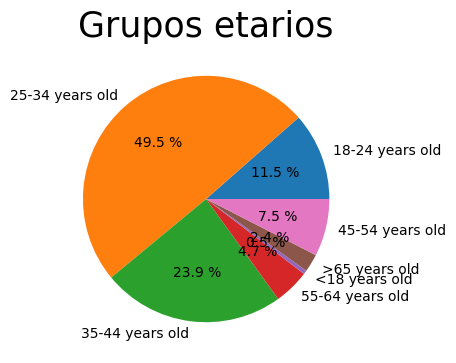

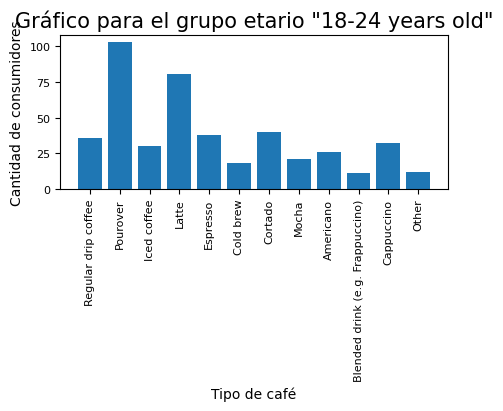

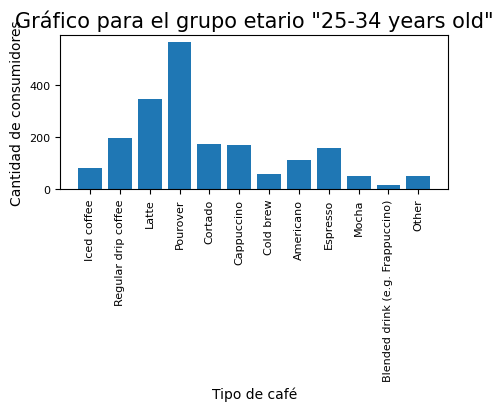

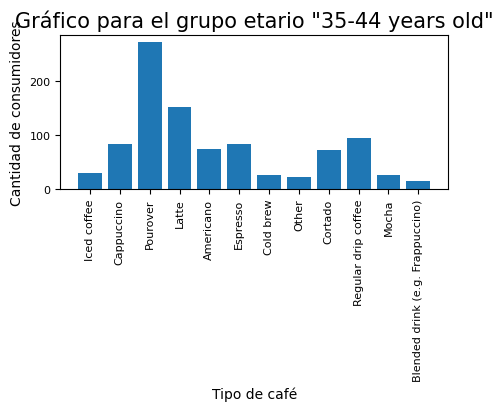

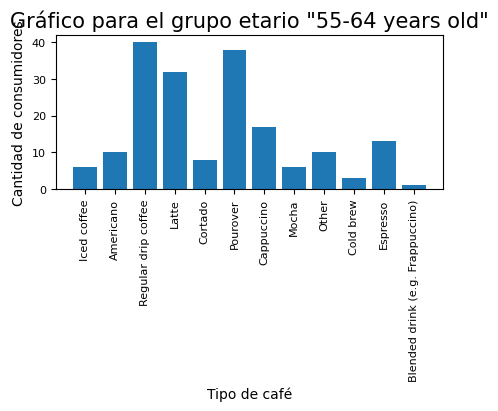

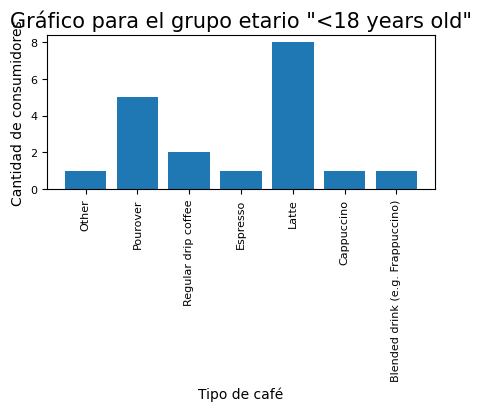

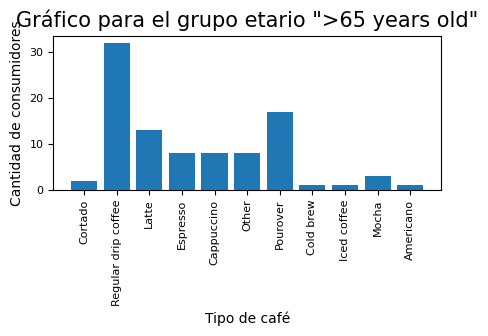

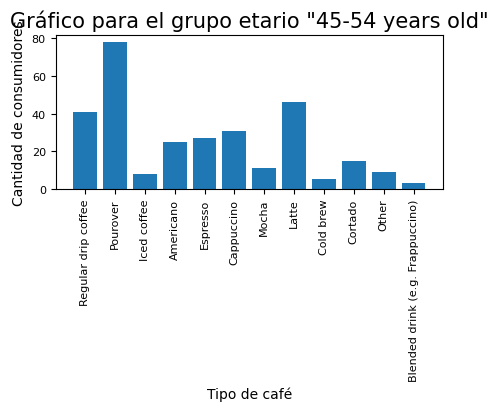

In [ ]:
# --- Gráficos --- #
encuesta_coffee_survey.graficar_grupos_etarios()
encuesta_coffee_survey.graficar_cafe_favorito_por_grupos_etarios()

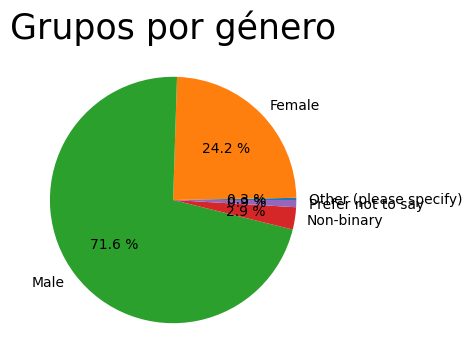

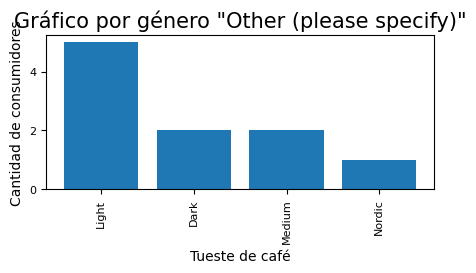

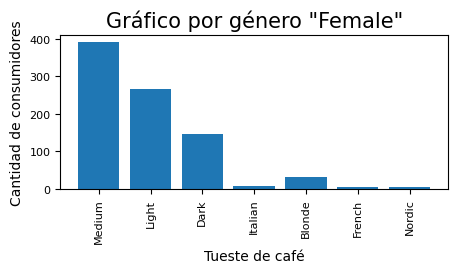

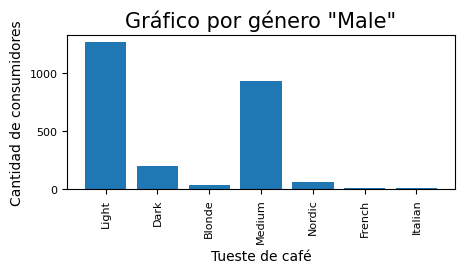

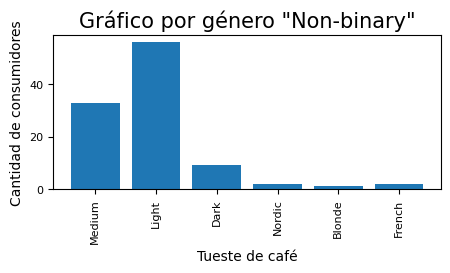

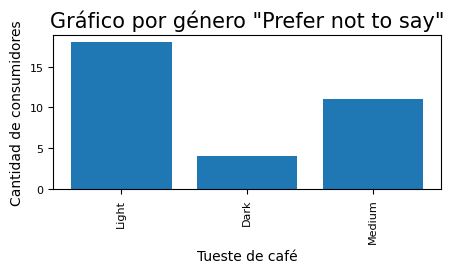

In [ ]:
'''
Vamos a dar los siguientes gráficos extra, que si bien no son pedidas en la
Consigna 12, nos ayudan a visualizar mejor los datos de la Encuesta segmentando
los niveles de tueste por género.
'''

plt.figure(figsize = (12,4))
plt.title('Grupos por género',fontsize=25) #titulo del gráfico y tamaño de la fuente
plt.pie(encuesta_coffee_survey.cantidades_generos.values(), labels  = encuesta_coffee_survey.cantidades_generos.keys(), autopct="%0.1f %%") #autopct="%0.1f %%" hace que aparezcan los porcentajes dentro de cada parte de la torta
for key in encuesta_coffee_survey.nivel_de_tueste_preferido_por_genero.keys():
  plt.figure(figsize = (5,2)) #para dar las dimensiones de la figura (ojo que debe ir arriba)
  plt.xticks(rotation = 90,fontsize=8); #rota las etiquetas del eje x y tamaño de la fuente de los valores del eje x
  plt.yticks(fontsize=8); #tamaño de la fuente de los valores del eje y
  plt.xlabel('Tueste de café',fontsize=10) #indica qué representa el eje x
  plt.ylabel('Cantidad de consumidores',fontsize=10) #indica qué representa el eje y
  plt.title(f'Gráfico por género "{key}"',fontsize=15) #titulo del gráfico y tamaño de la fuente
  plt.bar(encuesta_coffee_survey.nivel_de_tueste_preferido_por_genero[key].keys(), encuesta_coffee_survey.nivel_de_tueste_preferido_por_genero[key].values()) #pasamos los datos a graficar

**13-** **Conclusiones:**

Realice un análisis exhaustivo de los datos cargados en el objeto de tipo `Encuesta` recién creado. ¿Qué información relevante se puede extraer? Puede ayudarse de métodos del objeto para ver los gráficos o imprimir en pantalla información de este objeto. Reflexione sobre las conclusiones que se pueden obtener a partir de esta información.

Además, ¿qué recomendaciones ofrecería a su cliente para optimizar su cafetería? Por ejemplo, ¿a qué segmentos de clientes debería orientar su campaña de marketing para maximizar el impacto y atraer a más consumidores?

*Complete aquí sus conclusiones*

El objeto `Encuesta` recopila datos valiosos sobre las preferencias de café, incluyendo gustos favoritos según tipo de preparación, preferencias de tueste, distribuidos por grupos de edad y género, respectivamente. Esta información es fundamental para la toma de decisiones estratégicas en el manejo de nuestro negocio (podemos suponer que somos dueños de una cafetería) ya que permite:
* Identificar los productos más demandados y el público objetivo,
* Comprender las preferencias por segmentos etarios, y
* Optimizar la oferta y experiencia para este público objetivo.

### Análisis de los datos.

Observando el gráfico de torta (ver gráficos en la Consigna 12) podemos dividir a los encuestados en tres grupos según su edad y el porcentaje que representan:
* *Grupo predominante:* 25-34 años (≈50% de los encuestados),
* *Segundo grupo relevante:* 34-44 años (≈24% de participación), y
* *Otros grupos:* Menores de 18 y mayores de 44 (muestran participación menor).

Por otro lado, observando los gráficos de barras podemos destacar que en personas menores de 18 años tienen menor diversidad en preferencias, y gustos más básicos y tradicionales; Mientras que en personas mayores de 18 años tienen mayor variedad en preferencias y hay un incremento en la sofisticación de gustos.

Más aún, notamos que en general los tipos de café más elegidos son
- Latte,
- Regular drip coffee, y
- Pourover,

y los tipos de tuestes preferidos son
- Medium,
- Dark, y
- Light.

Observemos que en este último caso, si bien está segmentado por género, parece que la tendencia a elegir estos tres tipos de tuestes es muy marcada.

Por último, también vamos a notar que el grado académico de la mayoría de los encuestados es "Bachelor's degree". Esto sugiere que gran parte de la población encuestada está insertada en el ámbito laboral y cumple con horarios de trabajo regulares.

### Estrategias.

En base a los datos anteriores, damos las siguientes recomendaciones estratégicas:

1. **Segmentación del público objetivo**. Definimos como público objetivo a las personas de entre 25 y 44 años (r
epresentan ≈74% de la muestra). Recomendamos que la ambientación y los horarios del negocio deben ser acorde al perfil de estas personas. Más específicamente, las acciones recomendadas son:
  - Diseño que combine funcionalidad, por ejemplo para el trabajo y comodidad para poder socializar,
  - Iluminación adecuada para diferentes momentos del día,  
  - Selección musical que le guste a este grupo etario (por ejemplo mezcla de música contemporánea y clásicos),  
  - Extender horario matutino para captar público laboral,  
  - Considerar horario vespertino para reuniones mas informales.

2. **Menú**. Enfocar recursos en las variedades más populares (Latte, Regular drip coffee y Pourover) y los tipos de tuestes preferios (medium, dark y light) pero manteniendo una selección limitada de otras variedades para completar la oferta.

3. **Campañas de Marketing**. Podemos centrar el Marketing para atraer personas del público objetivo. Considerando su rango de edad, el enfoque principal puede ser los medios digitales (redes sociales, email) con mensajes que resalten la calidad y origen del café, la experiencia de consumo y el ambiente ideal para el trabajo y las reuniones sociales. Más específicamente, para personas entre 25 y 34 años, podemos hacer énfasis en productividad y encuentros sociales; Mientras que para personas entre 34 y 44 años, destacar calidad y experiencia sensorial.


### Conclusión.

Los datos indican claramente que el mayor potencial de mercado se encuentra en el segmento de **25-44 años**. Una estrategia enfocada en este grupo, con un menú que priorice sus preferencias y una ambientación acorde a sus gustos, **maximizará el atractivo del negocio y su rentabilidad**.